## Verify TSV file pairs data integrity

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matchms.importing import load_from_mgf
from matchms.plotting import plot_spectra_mirror
from matchms import Spectrum
from matchms.logging_functions import set_matchms_logger_level

# --- 1. CONFIGURATION ---
set_matchms_logger_level("ERROR")

In [30]:
# --- 1. CONFIGURATION ---
# Replace these with the specific IDs you want to check from your TSV
TARGET_GNPS_ID = "14502"
TARGET_MSG_ID = "MassSpecGymID0249439"
GNPS_MGF_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/spectra_pairs/ALL_GNPS_cleaned/batch_1.mgf"

MSG_SPEC_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
MSG_MOL_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"

In [31]:
# --- 2. LOAD DATA ---
print("Loading lookups...")
msg_spec = pd.read_pickle(MSG_SPEC_PATH)
msg_mol = pd.read_pickle(MSG_MOL_PATH)

Loading lookups...


In [32]:
# --- 3. EXTRACT SPECTRA ---
# A. Get GNPS Spectrum from MGF
print(f"Searching for GNPS ID: {TARGET_GNPS_ID}...")
gnps_spec = None
for s in load_from_mgf(GNPS_MGF_PATH):
    # Check both 'scans' and 'title' as IDs can vary by MGF source
    if str(s.get("scans")) == TARGET_GNPS_ID or str(s.get("title")) == TARGET_GNPS_ID:
        gnps_spec = s
        break

# B. Get MSG Spectrum from Dataframe
print(f"Searching for MSG ID: {TARGET_MSG_ID}...")
msg_row = msg_spec[msg_spec['spec_id'] == TARGET_MSG_ID].iloc[0]
msg_peaks = msg_row['peaks']
msg_mz, msg_inten = zip(*msg_peaks)

msg_spec_obj = Spectrum(mz=np.array(msg_mz), 
                        intensities=np.array(msg_inten), 
                        metadata={'precursor_mz': msg_row['prec_mz'], 'spec_id': TARGET_MSG_ID})

Searching for GNPS ID: 14502...
Searching for MSG ID: MassSpecGymID0249439...



--- MANUAL VERIFICATION DATA ---
GNPS ID: 14502
GNPS SMILES: CC(=O)NC(Cc1c[nH]c2ccccc12)C(=O)O
GNPS Precursor MZ: 247.108
------------------------------
MSG ID: MassSpecGymID0249439
MSG InChIKey: HNGIZKAMDMBRKJ
MSG Precursor MZ: 246.124
InChIKey Match (Skeleton): False


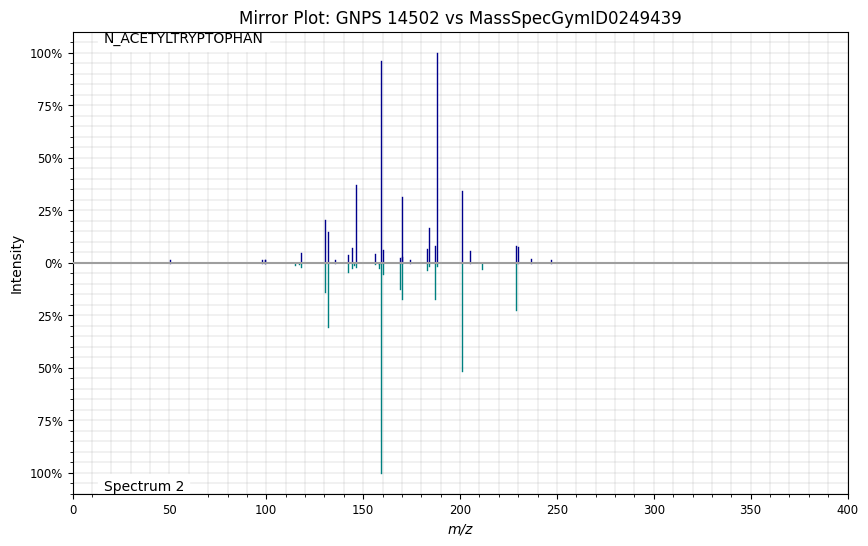

In [33]:
# --- 4. DATA INTEGRITY CHECKS ---
if gnps_spec is None:
    print("Error: GNPS Spectrum not found in provided MGF.")
else:
    # Get structural info for labels
    msg_mol_info = msg_mol[msg_mol['mol_id'] == msg_row['mol_id']].iloc[0]
    
    print("\n--- MANUAL VERIFICATION DATA ---")
    print(f"GNPS ID: {TARGET_GNPS_ID}")
    print(f"GNPS SMILES: {gnps_spec.get('smiles')}")
    print(f"GNPS Precursor MZ: {gnps_spec.get('precursor_mz')}")
    print("-" * 30)
    print(f"MSG ID: {TARGET_MSG_ID}")
    print(f"MSG InChIKey: {msg_mol_info['inchikey_s']}")
    print(f"MSG Precursor MZ: {msg_row['prec_mz']}")
    
    # Check if they are truly different molecules
    gnps_inchi = gnps_spec.get("inchikey", "Unknown")[:14]
    msg_inchi = msg_mol_info['inchikey_s'][:14]
    print(f"InChIKey Match (Skeleton): {gnps_inchi == msg_inchi}")

    # --- 5. PLOT MIRROR ---
    # Modified Cosine visualizes shifted peaks. 
    # Matchms plot_spectra_mirror shows them back-to-back.
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_spectra_mirror(gnps_spec, msg_spec_obj, ax=ax)
    ax.set_title(f"Mirror Plot: GNPS {TARGET_GNPS_ID} vs {TARGET_MSG_ID}")
    plt.show()